# Synapse Tuner
Adapted from bmtool/....


Configure and load cell before using.

In [1]:
import os, sys, json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from allensdk.api.queries.biophysical_api import BiophysicalApi
from allensdk.model.biophys_sim.config import Config
from allensdk.model.biophysical.utils import Utils

# Lightweight bootstrap for kernels launched outside repo root.
try:
    from modules.notebook_helpers import ensure_scp_repo_on_syspath
except ModuleNotFoundError:
    start = Path.cwd().resolve()
    injected = False
    for cand in (start, *start.parents):
        if (cand / "modules").is_dir() and (cand / "run_pipeline.py").is_file():
            if str(cand) not in sys.path:
                sys.path.insert(0, str(cand))
            injected = True
            break

    if not injected:
        for base in (start, start.parent):
            try:
                for child in base.iterdir():
                    if child.is_dir() and (child / "modules").is_dir() and (child / "run_pipeline.py").is_file():
                        if str(child) not in sys.path:
                            sys.path.insert(0, str(child))
                        injected = True
                        break
                if injected:
                    break
            except Exception:
                pass

    from modules.notebook_helpers import ensure_scp_repo_on_syspath

repo_root = ensure_scp_repo_on_syspath()

from modules import run_sim


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport
--No graphics will be displayed.


# Local Cell Bundle

In [ ]:
cell_name = 'SST' # SST, PV, PN
model_dir = 'seg_tuned'

cell_dir = repo_root / 'cells' / cell_name
if not cell_dir.is_dir():
    raise FileNotFoundError(f"Cell directory not found: {cell_dir}")
os.chdir(cell_dir)
print('CWD:', Path.cwd())


from pathlib import Path
import json

cfg_path = Path('tunes') / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path('tunes') / model_dir / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = repo_root / 'cells' / cell_name / 'tunes' / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = repo_root / 'cells' / cell_name / 'tunes' / model_dir / "sim_config.json"
if cfg_path.is_file():
    sim_cfg_preview = json.loads(cfg_path.read_text())


from pathlib import Path

bundle_dir = Path('tunes') / model_dir
required_paths = [
    bundle_dir / "manifest.json",
    bundle_dir / "modfiles",
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    missing_text = "\n".join(missing)
    raise FileNotFoundError(
        f"Missing required local cell bundle files:\n{missing_text}\n"
        "Prepare/download the bundle in Step 0, then rerun this notebook."
    )

print(f"Using existing local model bundle: {bundle_dir.resolve()}")


CWD: /home/hrbncv/SCP/cells/SST
Using existing local model bundle: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned


### Load Precompiled Mechanisms (from Step 0)

In [3]:
tune_dir = repo_root / 'cells' / cell_name / 'tunes' / model_dir
if not tune_dir.is_dir():
    raise FileNotFoundError(f"Tune directory not found: {tune_dir}")
os.chdir(tune_dir)

from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()

mech_candidates = [
    Path("modfiles/x86_64/.libs/libnrnmech.so"),
    Path("modfiles/x86_64/libnrnmech.so"),
]

mech_path = next((p for p in mech_candidates if p.is_file()), None)
if mech_path is None:
    raise FileNotFoundError(
        "Could not find compiled NEURON mechanisms. Expected one of: "
        + ", ".join(str(p) for p in mech_candidates)
        + "\nRun Step 0 to compile modfiles, or use the Colab notebook variant that bootstraps compilation."
    )

h.nrn_load_dll(str(mech_path))
print(f"Loaded mechanisms: {mech_path}")


Loaded mechanisms: modfiles/x86_64/.libs/libnrnmech.so


# Build Cell

In [4]:
from modules.notebook_helpers import (
    add_single_synapse_for_notebook,
    build_synapse_test_cell,
    resolve_cell_config_for_notebook,
)

cell_config_for_build = resolve_cell_config_for_notebook(cell_name)
cell = build_synapse_test_cell(cell_config_for_build)


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=10.0, Vinit=-65.0, loader=genome_fallback



First we must define some general settings and the settings for the connection we would like to tune. Below is an example of what this could look like for excitatory and inhibitory connections. Currently all of these settings, but the ones in the spec_syn_param are needed in order to use the tuner. You can copy all of the general_settings as these should be general enough to use for any case. The spec_settings are going to depend on your exact use case and connection type. 

In [5]:
syn_tuned = 'Fac2SST' # 'Fac2SST', 'Dep2PV', 'Inh2SST', 'PV2SST'

general_settings = {
    'vclamp': True, # if vclamp should start on or off used mostly for singleEventv
    'rise_interval': (0.1, 0.9), #10-90%
    'tstart': 500., # when the singleEvent should start
    'tdur': 100.,    # Dur of sim after single synaptic event has occured
    'threshold': -15., #threshold for spike in mV
    'delay': 1.3, # netcon delay
    'weight': 1., # netcon weight
    'dt': 0.025, # simulation dt
    'celsius': 20 # temp of sim
}

conn_type_settings = {
    'Fac2SST': { # facilitating synapse 
        'spec_settings': {
            'post_cell': 'FSI_Cell', # not used when cell is pre-built
            'vclamp_amp' : -65, #PV/SST Vrest ??????????????????????????????????????? If so -71/-66 respectively
            'sec_x': 0.5, 
            'sec_id': 0, # 1 ???????????????????????????????????????
            "level_of_detail": "AMPA_NMDA_STP",
        },
        'spec_syn_param': {
            'initW': 0.25,
            'tau_r_AMPA': 0.2, #4
            'tau_d_AMPA': 1.7, #5
            'Use': 0.75,
            'Dep': 0.0,
            'Fac': 200.0,
            'NMDA_ratio': 1.5,
        },
    },
    'Dep2PV': { # depressing synapse
        'spec_settings': {
            'post_cell': 'FSI_Cell',
            'vclamp_amp': -71,
            'sec_x': 0.5,
            'sec_id': 0,
            "level_of_detail": "AMPA_NMDA_STP",  #"GABA_A_STP",
        },
        'spec_syn_param': {
            'initW': 1.5,
            'tau_r_AMPA': 3.5,
            'tau_d_AMPA': 4,
            # 'tau_r_GABAA': 0.9,
            # 'tau_d_GABAA': 15,
            # 'e_GABAA':-75,
            'Use': 0.80,
            'Dep': 100.0,
            'Fac': 0.0,
            'NMDA_ratio': 0.0,
        },
    },
    'Inh2SST': {    # (bg) inhibitory synapse to SST
        'spec_settings': {
            'post_cell': 'FSI_Cell',
            'vclamp_amp': -65, 
            'sec_x': 0.5,
            'sec_id':0,
            "level_of_detail": "GABA_A",  #"GABA_A_STP",
        },
        'spec_syn_param': {
            'initW': 0.1, #0.1 SST/ 2.0 PV #20 
            'tau_r_GABAA': 0.5, #0.9,
            'tau_d_GABAA': 5.5, #15,
            'e_GABAA': -75, #-75
            'gmax': 0.001, #0.001 uS
            # 'Use': 0., #0.4
            # 'Dep': 0., #190
            # 'Fac': 0. #0
        },
    },
    'PV2SST': {    # (bg) inhibitory synapse to SST
        'spec_settings': {
            'post_cell': 'FSI_Cell',
            'vclamp_amp': -65, 
            'sec_x': 0.5,
            'sec_id':0,
            "level_of_detail": "GABA_A_STP",  #"GABA_A_STP",
        },
        'spec_syn_param': {
            'initW': 5.0, #0.1 SST/ 2.0 PV #20 
            'tau_r_GABAA': 0.5, #0.9,
            'tau_d_GABAA': 5.5, #15,
            'e_GABAA': -75, #-75
            'gmax': 0.001, #0.001 uS
            'Use': 1., #0.4
            'Dep': 250., #190
            'Fac': 0. #0
        },
    },

}

In [6]:
cell = build_synapse_test_cell(cell_config_for_build)

syn_loc = cell.h.soma[0](0.5)
syn_params = conn_type_settings[syn_tuned]
spike_train = [400,500,600,700,800]

add_single_synapse_for_notebook(cell, syn_loc, syn_params, spike_train)

sim_params = {
    'dt': 0.025, # ms
    'tstop': 2500.0, # ms
}

sim_traces = run_sim.run_cell(cell,sim_params)


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=10.0, Vinit=-65.0, loader=genome_fallback


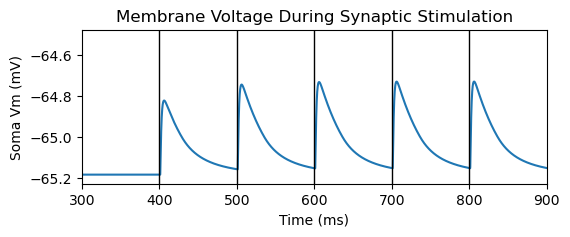

In [7]:
plt.figure(figsize=(6,2))
plt.plot(sim_traces['T'],sim_traces['V'],color=None)
for spk_time in spike_train:
    plt.axvline(x=spk_time, color='k', linewidth=1)
plt.xlim(300,900)
plt.xlabel('Time (ms)')
# plt.ylim(bottom=-68,top=-64.25)
plt.ylabel('Soma Vm (mV)')
plt.title('Membrane Voltage During Synaptic Stimulation')
plt.show()

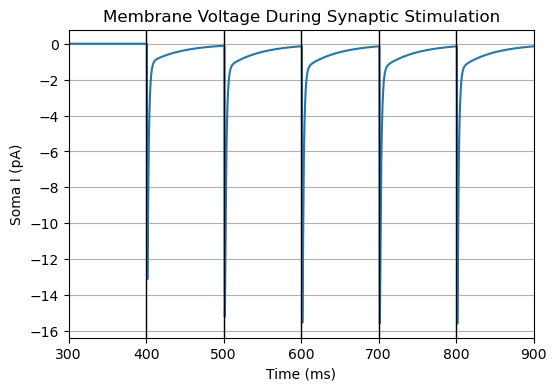

In [8]:
plt.figure(figsize=(6,4))
plt.plot(sim_traces['T'],sim_traces['I']*1000,color=None)
for spk_time in spike_train:
    plt.axvline(x=spk_time, color='k', linewidth=1)
plt.xlim(300,900)
plt.xlabel('Time (ms)')
# plt.ylim(bottom=None,top=-64.32)
plt.ylabel('Soma I (pA)')
plt.title('Membrane Voltage During Synaptic Stimulation')
plt.grid()
plt.show()

## initialize tuner
Now we can initialize the synaptic tuner. You must call the SingleEvent method before using the interactiveTuner. When initializing you will have to change a few arguments depending on your use case. other_vars_to_record can be any variable in your synaptic mechanism, while slider_vars can be any range variable you wish to tune in the synapse. If the variable is not defined in the spec_syn_param than the tuner will get the value from the mechanism and try to set up some sliders to tune it.

In [9]:
cell = build_synapse_test_cell(cell_config_for_build)


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=10.0, Vinit=-65.0, loader=genome_fallback


In [10]:
from pathlib import Path

from modules.notebook_helpers import ensure_external_repo_on_syspath

bmtool_path = ensure_external_repo_on_syspath(
    repo_name='bmtool',
    marker_rel=Path('bmtool') / 'synapses.py',
    env_vars=('SCP_BMTOOL_PATH', 'BMTOOL_PATH', 'BMTOOL_ROOT'),
    repo_root=repo_root,
)

from bmtool.synapses import SynapseTuner
from bmtool.synapses import SynapseOptimizer


In [11]:
# syn_tuned = 'Dep2PV'

# Initialize our tuner
if syn_tuned in ['InhSST', 'Inh2PV',]:
    tuner = SynapseTuner(
        mechanisms_dir='.', # where x86_64 is located
        # mechanisms_dir=mechanisms_dir, # where x86_64 is located
        # templates_dir=templates_file, # where the neuron templates are located

        conn_type_settings=conn_type_settings, # dict of connection settings
        general_settings = general_settings, # dict of general settings

        connection = 'Inh2SST', # key in connection settings for which connection you want to tune
        #json_folder_path=json_folder_path, # If your network uses json files the path can be set to update the connection settings based on the keys and values in the json
        
        current_name = 'i', # name of current variable in synapase
        other_vars_to_record = ['g',], #'gmax_GABAA',], #'v','factor_GABAA'], # Other synaptic variables you wish to record besides the normal ones
        slider_vars=['initW','tau_r_GABAA','tau_d_GABAA','gmax'], # Range variables you want to tune to adjust synaptic response.

        hoc_cell = cell, # cell generated above
    )
elif syn_tuned in ['PV2SST']:
    tuner = SynapseTuner(
        mechanisms_dir='.', # where x86_64 is located
        # mechanisms_dir=mechanisms_dir, # where x86_64 is located
        # templates_dir=templates_file, # where the neuron templates are located

        conn_type_settings=conn_type_settings, # dict of connection settings
        general_settings = general_settings, # dict of general settings

        connection = syn_tuned, # key in connection settings for which connection you want to tune
        #json_folder_path=json_folder_path, # If your network uses json files the path can be set to update the connection settings based on the keys and values in the json
        
        current_name = 'i', # name of current variable in synapase
        other_vars_to_record = ['g',], #'gmax_GABAA',], #'v','factor_GABAA'], # Other synaptic variables you wish to record besides the normal ones
        slider_vars=['initW','Dep','Fac','Use','tau_r_GABAA','tau_d_GABAA','gmax'], # Range variables you want to tune to adjust synaptic response.

        hoc_cell = cell, # cell generated above
    )
elif syn_tuned in ['Fac2SST', 'Dep2PV']:
    tuner = SynapseTuner(
        mechanisms_dir='.', # where x86_64 is located
        # mechanisms_dir=mechanisms_dir, # where x86_64 is located
        # templates_dir=templates_file, # where the neuron templates are located

        conn_type_settings=conn_type_settings, # dict of connection settings
        general_settings = general_settings, # dict of general settings

        connection = syn_tuned, # key in connection settings for which connection you want to tune
        #json_folder_path=json_folder_path, # If your network uses json files the path can be set to update the connection settings based on the keys and values in the json
        
        current_name = 'i', # name of current variable in synapase
        other_vars_to_record = ['record_Pr', 'record_use'], # Other synaptic variables you wish to record besides the normal ones
        slider_vars=['initW','Dep','Fac','Use','tau_r_AMPA','tau_d_AMPA'],

        hoc_cell = cell, # cell generated above
    )

else:
    print('Please choose valid syn from conn_type_settings to tune!!!')

## SingleEvent 
The SingleEvent method will run a short pulse and then print out the synaptic properties for the synapse.  

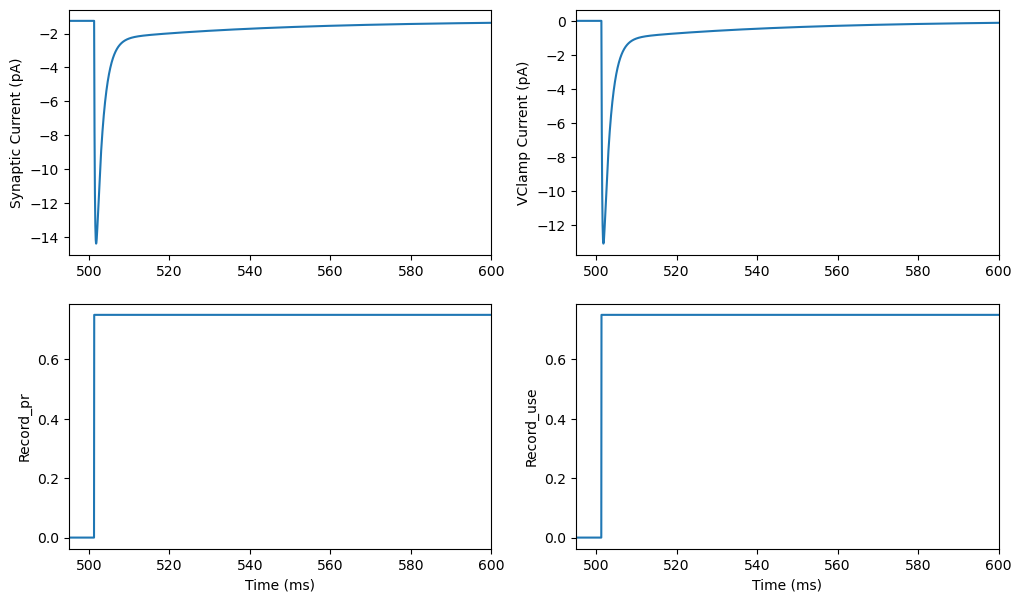

('baseline', 0.001256182403082562)
('sign', -1.0)
('latency', 1.35)
('amp', 0.013103819407817241)
('rise_time', 0.275)
('decay_time', 2.5002596697405512)
('half_width', 3.2750000000000004)
Current Integral in pA*ms: -824.87


In [12]:
tuner.SingleEvent()

## InteractiveTuner
The InteractiveTuner will deliver an input to the cell at a desired weight and frequency. The frequency by default will be 8 spikes then a 250ms delay and then 4 more spikes. 

Paired-pulse ratio is (Avg 2nd pulse - Avg 1st pulse) ÷ 90th percentile amplitude.

Induction is (Avg (6th, 7th, 8th pulses) - Avg 1st pulse) ÷ 90th percentile amplitude. 

Recovery is (Avg (9th, 10th, 11th, 12th pulses) - Avg (1st, 2nd, 3rd, 4th pulses)) ÷ 90th percentile amplitude

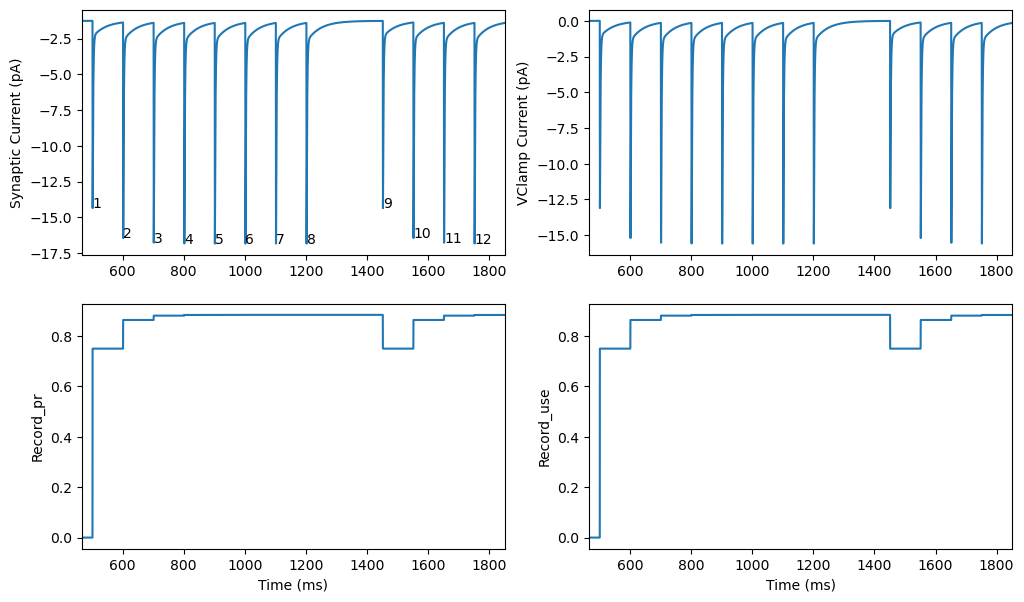


Short Term Plasticity Results for 10Hz with 250 Delay
PPR: Above 1 is facilitating, below 1 is depressing.
Induction: Above 0 is facilitating, below 0 is depressing.
Recovery: A measure of how fast STP decays.

Paired Pulse Response (PPR)
Calculation: 2nd pulse / 1st pulse
Values: ([[16.46]]) / ([[14.36]]) = [[1.15]]

Induction
Calculation: (avg(6th, 7th, 8th pulses) - 1st pulse) / max amps
Values: avg([[16.85, 16.85, 16.85]]) - [[14.36]] / [16.85]
([16.85]) - ([14.36]) / [16.85] = 0.148

Recovery
Calculation: (avg(9th, 10th, 11th, 12th pulses) - avg(1st to 4th pulses)) / max amps
Values: avg([[14.36, 16.46, 16.79, 16.84]]) - avg([[14.36, 16.46, 16.79, 16.84]]) / [16.85]
([16.11]) - ([16.11]) / [16.85] = 0.000




In [13]:
tuner.InteractiveTuner()

In [14]:
err

NameError: name 'err' is not defined

    ## Frequency reponse
We can also see how the STP parameters vary with different train frequencies 

Analyzing frequencies:   0%|          | 0/16 [00:00<?, ?it/s]

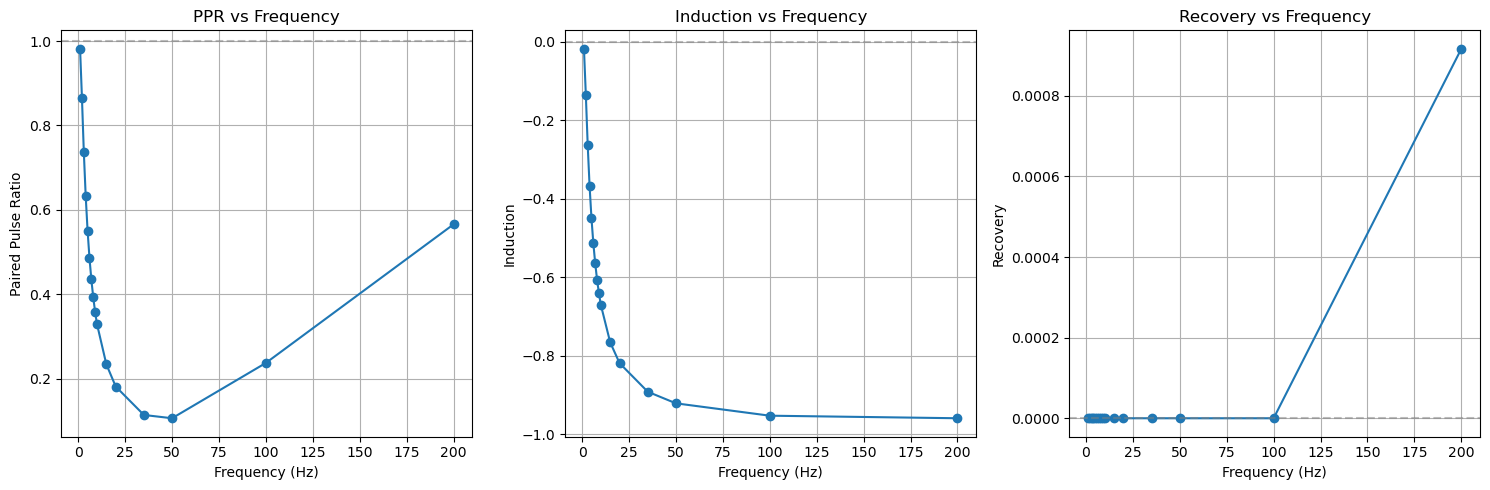

In [ ]:
results = tuner.stp_frequency_response(log_plot=False)

In [ ]:
err

NameError: name 'err' is not defined

## SynapseOptimizer
If we don't feel like tuner by hand we can also try to optimize an output of our model. In this example we will optimize and find the best STP parameters that give the induction and paired pulse response we want. Something to note is that the optimizer does not know what the trace should look like and only knows the features. So it might get some wild trace that happens to work. Also if you are using the random init_guess and don't like the voltage trace then run it again. The seed is different each time so the optimization will be different and can result in a better fit.

In [ ]:
# Create the optimizer
optimizer = SynapseOptimizer(tuner)

# Define parameter bounds these can be any range variable you wish to tune
param_bounds = {
    'Dep': (0, 200.0),
    'Fac': (0, 400.0),
    'Use': (0.1, 1.0),
    'tau_r_AMPA': (1,4), # tau r needs to be less than tau d so be careful
    'tau_d_AMPA': (5,20)
}

# Define target metrics these are the metrics that the tuner will try to automatic get the synapse to respond with
# max amps is an absolute value
target_metrics = {
    'induction': -0.75,
    'ppr': 0.8,
    'recovery': 0.0,
    'max_amplitude': 25,     # note if you get rid of the max amps in the cost function the fit will normally be better. Then you could scale the max amps with the initW
    'rise_time': 2,          # This wont always be the case, but for this synapse Use controls STP and max amps so it can sometimes struggle to fit.
    'decay_time': 9
}

# currently the only metrics in the SynapseOptimizer are induction, prr, recovery, and max amplitude for train
# for SingleEvent there is just rise and decay time
# error will be constant if not running that case
def custom_cost(metrics, targets):
    # equal zero unless using train input
    induction_error = (metrics['induction'] - targets['induction']) ** 2
    ppr_error = (metrics['ppr'] - targets['ppr']) ** 2
    recovery_error = (metrics['recovery'] - targets['recovery']) ** 2
    max_amp_errror = (metrics['max_amplitude'] - targets['max_amplitude']) ** 2
    # equal zero unless using SingleEvent
    rise_time_error = (metrics['rise_time'] - targets['rise_time']) ** 2
    decay_time_error = (metrics['decay_time'] - targets['decay_time']) ** 2 

    #return rise_time_error + decay_time_error
    return induction_error + 3 * ppr_error + recovery_error + rise_time_error + decay_time_error #+ 0.5*max_amp_errror

# Run optimization with custom cost function
result = optimizer.optimize_parameters(
    target_metrics=target_metrics,
    param_bounds=param_bounds,
    run_single_event=True,  # Run and use parameters from SingleEvent
    run_train_input=True,   # Run and use parameters from train input 
    train_frequency=50,     # Freq in Hz of train input
    train_delay=250,        # delay in ms of second train
    init_guess='random',    # either random or middle_guess. Random will start the synapse witha random value in the param_bound. Middle guess will pick the middle value in the param_bounds
    cost_function=custom_cost,
    method='SLSQP'          # I believe this will be the fastest method, but you may try others check out https://docs.scipy.org/doc/scipy-1.15.0/reference/generated/scipy.optimize.minimize.html
                            # SLSQP is a gradient based method while nelder-mead is simplex (whatever that means)
)

# Plot results
optimizer.plot_optimization_results(result)

## Extra notes
If there is a need for faster optimization with more parameters or more complex metrics the SynapseOptimize could be modifed to use [jax](https://jax.readthedocs.io/en/latest/index.html) and the [scipy method](https://jax.readthedocs.io/en/latest/_autosummary/jax.scipy.optimize.minimize.html). I did not look into this much as my use case currently only takes around 1 min to optimize. Also for the example provided it is important to note that we are using bounded optimizing methods since the Use parameter can not go above one. If there is a case where the parameters have no upper or lower bounds one could look into other optimizing methods